IMPORTING LIBRARIES

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

LOAD DATASET

In [141]:
credit_card_data=pd.read_csv("../dataset/creditcard.csv")

In [142]:
#print first 5 rows of the dataset

credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [143]:
#print last 5 rows of the dataset

credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Dataset Shape--->

Know how many rows and columns.

In [144]:
credit_card_data.shape

(284807, 31)

Dataset Information

In [145]:
credit_card_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [146]:
credit_card_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Checking dataset having missing values


In [147]:
credit_card_data.isnull().sum().head(20)

Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
V10     0
V11     0
V12     0
V13     0
V14     0
V15     0
V16     0
V17     0
V18     0
V19     0
dtype: int64

In [148]:
credit_card_data.isnull().sum().tail(11)

#No missing value in data

V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [149]:
credit_card_data.duplicated().sum()  #--->duplicate exits,remove them.

np.int64(1081)

Remove Duplicate

In [150]:
credit_card_data=credit_card_data.drop_duplicates()

check again duplicate

In [151]:
credit_card_data.duplicated().sum() #--->No duplicate exits

np.int64(0)

In [152]:
credit_card_data.shape

(283726, 31)

Distribution of legit & fraudulent transactions

In [153]:
credit_card_data["Class"].value_counts()

#The data is drastic imbalanced

#0-->Normal Transaction
#1-->Fraud Transaction

Class
0    283253
1       473
Name: count, dtype: int64

In [154]:
credit_card_data["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

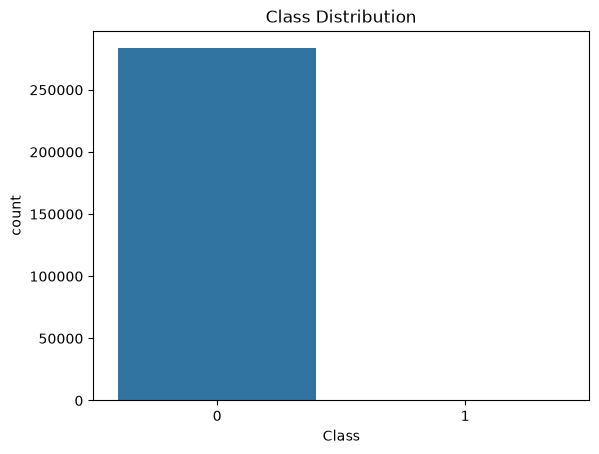

In [155]:
sns.countplot(x="Class", data=credit_card_data)
plt.title("Class Distribution")
plt.show()

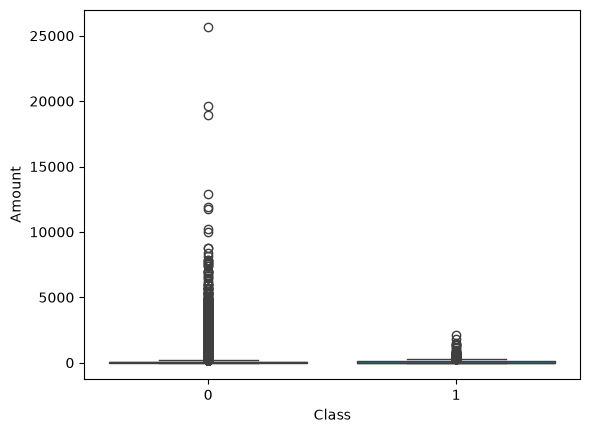

In [156]:
sns.boxplot(x="Class", y="Amount", data=credit_card_data)
plt.show()

In [157]:
fraud= credit_card_data[credit_card_data["Class"] == 1]
normal= credit_card_data[credit_card_data["Class"] == 0]

In [158]:
fraud.shape

(473, 31)

In [159]:
normal.shape

(283253, 31)

In [160]:
normal["Amount"].describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [161]:
fraud["Amount"].describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

UnderSampling -->Build a sample dataset containing similar distribution Normal & Fraud Transaction-->No. of FraudTransaction--->473

##UnderSampling
#-->The dataset is highly imbalanced. To avoid bias toward the majority class, random undersampling is performed by selecting the same number of normal transactions as fraudulent transactions.

In [162]:
normal_df=normal.sample(n=473)

Concatenate both df

In [163]:
new_data=pd.concat([normal_df,fraud],axis=0)  #concat rows wise

In [164]:
# Save the balanced dataset

new_data.to_csv("../dataset/credit_card_balanced.csv", index=False)

In [165]:
new_data.shape

(946, 31)

In [166]:
new_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
66722,52187.0,-1.200997,0.284409,0.489564,-0.046255,1.077751,4.541955,-0.125903,1.524417,-0.453496,...,0.159223,-0.060253,0.216206,0.978499,0.484373,-0.255234,-0.066309,0.038561,211.32,0
131386,79581.0,1.211179,0.629518,-0.454915,0.898727,0.154172,-1.170856,0.351626,-0.210283,-0.219400,...,-0.102877,-0.197196,-0.015637,0.293078,0.460261,0.377815,-0.012643,0.043141,0.76,0
25548,33661.0,-0.103012,1.147251,-1.706161,-0.196730,2.558567,3.067302,0.079616,1.159481,-0.822466,...,0.123372,0.291481,0.036719,1.004913,-0.528645,-0.397351,0.316124,0.161623,4.99,0
111518,72253.0,-1.606235,-0.762396,2.800649,-0.444450,-0.082899,-0.621209,-0.783493,0.179658,0.889285,...,0.176546,0.782956,-0.359025,0.547606,-0.189433,1.021601,0.087362,0.058488,58.92,0
162801,115379.0,1.191263,-1.802019,-0.923182,0.251284,-1.021202,-0.061141,-0.211457,0.115891,1.176260,...,0.120518,-0.622541,0.081185,0.707457,-0.742796,-0.370099,-0.089345,0.028324,409.58,0


In [167]:
"""
0
0
0
0
0
...
1
1
1
1
1
"""
#your class column will look like this after concatenation of rows
#however will train_test_split will take care of the shuffling of rows and will make sure that the data is balanced in both train and test data.


'\n0\n0\n0\n0\n0\n...\n1\n1\n1\n1\n1\n'

In [168]:
new_data["Class"].value_counts()


#data is Balanced

Class
0    473
1    473
Name: count, dtype: int64

In [169]:
new_data.groupby("Class").mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,93837.038055,-0.035107,-0.111292,0.032103,-0.156025,-0.016547,-0.064877,0.065568,0.011578,-0.039806,...,0.072154,-0.055972,0.003418,0.008441,0.030640,0.011293,0.015327,0.004220,0.00206,98.503129
1,80450.513742,-4.498280,3.405965,-6.729599,4.472591,-2.957197,-1.432518,-5.175912,0.953255,-2.522124,...,0.405043,0.466550,0.086639,-0.096464,-0.106643,0.040615,0.050456,0.213774,0.07827,123.871860


Splitting data in Feature & Target

In [170]:
x=new_data.drop(columns="Class")
y=new_data["Class"]

In [171]:
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
66722,52187.0,-1.200997,0.284409,0.489564,-0.046255,1.077751,4.541955,-0.125903,1.524417,-0.453496,...,0.514319,0.159223,-0.060253,0.216206,0.978499,0.484373,-0.255234,-0.066309,0.038561,211.32
131386,79581.0,1.211179,0.629518,-0.454915,0.898727,0.154172,-1.170856,0.351626,-0.210283,-0.219400,...,-0.101503,-0.102877,-0.197196,-0.015637,0.293078,0.460261,0.377815,-0.012643,0.043141,0.76
25548,33661.0,-0.103012,1.147251,-1.706161,-0.196730,2.558567,3.067302,0.079616,1.159481,-0.822466,...,0.061338,0.123372,0.291481,0.036719,1.004913,-0.528645,-0.397351,0.316124,0.161623,4.99
111518,72253.0,-1.606235,-0.762396,2.800649,-0.444450,-0.082899,-0.621209,-0.783493,0.179658,0.889285,...,-0.182727,0.176546,0.782956,-0.359025,0.547606,-0.189433,1.021601,0.087362,0.058488,58.92
162801,115379.0,1.191263,-1.802019,-0.923182,0.251284,-1.021202,-0.061141,-0.211457,0.115891,1.176260,...,0.544022,0.120518,-0.622541,0.081185,0.707457,-0.742796,-0.370099,-0.089345,0.028324,409.58


In [172]:
y.head()

66722     0
131386    0
25548     0
111518    0
162801    0
Name: Class, dtype: int64

TRAIN TEST SPLIT DATA

In [173]:
from sklearn.model_selection import train_test_split

In [174]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [175]:
x_train.shape

(756, 30)

In [176]:
x_test.shape

(190, 30)

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

1] LOGISTIC REGRESSION MODEL

In [178]:
lr=LogisticRegression(max_iter=1000) 
lr.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [179]:
y_pred=lr.predict(x_test)

In [180]:
x_train_score=lr.score(x_train,y_train)
x_test_score=lr.score(x_test,y_test)

In [181]:
x_train_score

0.9523809523809523

In [182]:
x_test_score

0.9526315789473684

model work perfectly NO -->Overfitting and Underfitting

In [183]:
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test,y_pred))

Accuracy of Logistic Regression model is: 0.9526315789473684


In [184]:
from sklearn.metrics import confusion_matrix, classification_report

In [185]:
print(confusion_matrix(y_test,y_pred))

[[87  1]
 [ 8 94]]


In [186]:
confusion_df=pd.DataFrame(confusion_matrix(y_test,y_pred), columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])    

In [187]:
confusion_df

,Predicted Normal,Predicted Fraud
Actual Normal,87,1
Actual Fraud,8,94


In [188]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [189]:
print("precision_score:", precision_score(y_test,y_pred))

precision_score: 0.9894736842105263


In [190]:
print("recall_score:", recall_score(y_test,y_pred))

recall_score: 0.9215686274509803


In [191]:
print("f1_score:", f1_score(y_test,y_pred))

f1_score: 0.9543147208121827


In [192]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        88
           1       0.99      0.92      0.95       102

    accuracy                           0.95       190
   macro avg       0.95      0.96      0.95       190
weighted avg       0.96      0.95      0.95       190



Hyperparameter tuning-->Logistic Regression


In [193]:
from sklearn.model_selection import GridSearchCV

In [194]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs"],
    "max_iter": [500, 1000, 1500, 2000],
    "penalty": ["l2"]
}

In [195]:
grid=GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='accuracy')

In [196]:
grid.fit(x_train,y_train)

c:\PROJECTS\credit_card_detection\creditcardvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\PROJECTS\credit_card_detection\creditcardvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\PROJECTS\

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [197]:
print(grid.best_params_)

{'C': 100, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}


In [198]:
lr2=LogisticRegression(C=grid.best_params_['C'], solver=grid.best_params_['solver'], max_iter=grid.best_params_['max_iter'], penalty=grid.best_params_['penalty'])

In [199]:
lr2.fit(x_train,y_train)

c:\PROJECTS\credit_card_detection\creditcardvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To

In [200]:
y_pred2=lr2.predict(x_test)

In [201]:
x_train_score2=lr2.score(x_train,y_train)
x_test_score2=lr2.score(x_test,y_test)

In [202]:
x_train_score

0.9523809523809523

In [203]:
x_test_score

0.9526315789473684

In [204]:
print(accuracy_score(y_test,y_pred2))

0.9526315789473684


2]  DECISION TREE

In [205]:
from sklearn.tree import DecisionTreeClassifier

In [206]:
dt=DecisionTreeClassifier(random_state=42)

In [207]:
dt.fit(x_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [208]:
y_pred_dt=lr.predict(x_test)

In [209]:
x_train_score_dt=dt.score(x_train,y_train)
x_test_score_dt=dt.score(x_test,y_test)

In [210]:
x_train_score_dt

1.0

In [211]:
x_test_score_dt

0.9263157894736842

In [212]:
#accuracy

accuracy_dt = accuracy_score(y_test, y_pred_dt)

In [213]:
print("Accuracy_score_dt1:", accuracy_dt)

Accuracy_score_dt1: 0.9526315789473684


In [214]:
print("confusion_matrix_dt: ")
print()
print(confusion_matrix(y_test,y_pred_dt))

confusion_matrix_dt: 

[[87  1]
 [ 8 94]]


In [215]:
print("confusion_matrix_dt_df ")
print()
pd.DataFrame(confusion_matrix(y_test,y_pred_dt), columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])

confusion_matrix_dt_df 



,Predicted Normal,Predicted Fraud
Actual Normal,87,1
Actual Fraud,8,94


In [216]:
print("Precision_score_dt: ", precision_score(y_test,y_pred_dt))

Precision_score_dt:  0.9894736842105263


In [217]:
print("recall_score_dt: ",recall_score(y_test,y_pred_dt))

recall_score_dt:  0.9215686274509803


In [218]:
print(f1_score(y_test,y_pred_dt))

0.9543147208121827


In [219]:
print("classification_report_dt: ")
print()
print()
print( classification_report(y_test,y_pred_dt))

classification_report_dt: 


              precision    recall  f1-score   support

           0       0.92      0.99      0.95        88
           1       0.99      0.92      0.95       102

    accuracy                           0.95       190
   macro avg       0.95      0.96      0.95       190
weighted avg       0.96      0.95      0.95       190



HYPERPARAMETER TUNING--> decision tree

In [220]:
param_grid_dt= {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,10,15,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [221]:
grid_dt=GridSearchCV(dt,param_grid_dt,cv=5,scoring='accuracy')

In [222]:
grid_dt.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [223]:
print(grid_dt.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [224]:
dt1=DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=5,min_samples_leaf=2, random_state=42)

In [225]:
dt1.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [226]:
y_pred_dt1=dt1.predict(x_test)

In [227]:
x_train_score_dt1=dt1.score(x_train,y_train) #training score of decision tree model after hyperparameter tuning
x_test_score_dt1=dt1.score(x_test,y_test)  #testing score of decision tree model after hyperparameter tuning

In [228]:
x_train_score_dt1

0.9695767195767195

In [229]:
x_test_score_dt1

0.9210526315789473

In [230]:
#accuracy

accuracy_dt1 = accuracy_score(y_test, y_pred_dt1)

In [231]:
print("confusion_matrix_dt1: ")
print()
print(confusion_matrix(y_test,y_pred_dt1))

confusion_matrix_dt1: 

[[82  6]
 [ 9 93]]


In [232]:
print("confusion_matrix_dt1_df ")
print()
pd.DataFrame(confusion_matrix(y_test,y_pred_dt1), columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])

confusion_matrix_dt1_df 



,Predicted Normal,Predicted Fraud
Actual Normal,82,6
Actual Fraud,9,93


In [233]:
print("Accuracy_score_dt1: ", accuracy_dt1)

Accuracy_score_dt1:  0.9210526315789473


In [234]:
print("precision_score_dt1: ", precision_score(y_test,y_pred_dt1))

precision_score_dt1:  0.9393939393939394


In [235]:
print("recall_score_dt1: ",recall_score(y_test,y_pred_dt1))

recall_score_dt1:  0.9117647058823529


In [236]:
print("f1_score_dt1: ", f1_score(y_test,y_pred_dt1))

f1_score_dt1:  0.9253731343283582


In [237]:
print("classification_report_dt1: ")
print()
print()
print(classification_report(y_test,y_pred_dt1))

classification_report_dt1: 


              precision    recall  f1-score   support

           0       0.90      0.93      0.92        88
           1       0.94      0.91      0.93       102

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190



3]  KNN

In [238]:
from sklearn.neighbors import KNeighborsClassifier

In [239]:
knc=KNeighborsClassifier()

In [240]:
knc.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [241]:
y_pred_knc=knc.predict(x_test)

In [242]:
x_train_score_knc=knc.score(x_train,y_train) #training score of KNN model
x_test_score_knc=knc.score(x_test,y_test)  #testing score of KNN model

In [243]:
x_train_score_knc

0.9457671957671958

In [244]:
x_test_score_knc

0.9105263157894737

In [245]:
print("Accuracy_score_knc: ", accuracy_score(y_test,y_pred_knc))

Accuracy_score_knc:  0.9105263157894737


In [246]:
print("Confusion_matrix")
print(confusion_matrix(y_test,y_pred_knc))

Confusion_matrix
[[85  3]
 [14 88]]


In [247]:
print("Confusion_matrix_knc_df ")
pd.DataFrame(confusion_matrix(y_test,y_pred_knc), columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])

Confusion_matrix_knc_df 


,Predicted Normal,Predicted Fraud
Actual Normal,85,3
Actual Fraud,14,88


In [248]:
print("Accuracy_score_knc:",accuracy_score(y_test,y_pred_knc))

Accuracy_score_knc: 0.9105263157894737


In [249]:
print("recall_score_knc: ",recall_score(y_test,y_pred_knc))

recall_score_knc:  0.8627450980392157


In [250]:
print("F1_score_knc: ",f1_score(y_test,y_pred_knc))

F1_score_knc:  0.9119170984455959


In [251]:
print("classification_report_knc: ")
print()
print(classification_report(y_test,y_pred_knc))

classification_report_knc: 

              precision    recall  f1-score   support

           0       0.86      0.97      0.91        88
           1       0.97      0.86      0.91       102

    accuracy                           0.91       190
   macro avg       0.91      0.91      0.91       190
weighted avg       0.92      0.91      0.91       190



Hyperparameter tuning-->knc

In [252]:
param_grid_knc = {
    "n_neighbors":[3,5,7,9,11],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

In [253]:
grid_knc=GridSearchCV(knc,param_grid_knc,cv=5,scoring='accuracy')

In [254]:
grid_knc.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [255]:
print(grid_knc.best_params_)

{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


In [256]:
knc1=KNeighborsClassifier(n_neighbors=3,metric="manhattan", weights="uniform")

In [257]:
knc1.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'ma...an'


In [258]:
y_pred_knc1=knc1.predict(x_test)

In [259]:
x_train_score_knc1=knc1.score(x_train,y_train) #training score of KNN model after hyperparameter tuning
x_test_score_knc1=knc1.score(x_test,y_test)  #testing score of KNN model after hyperparameter tuning

In [260]:
x_train_score_knc1

0.955026455026455

In [261]:
x_test_score_knc1

0.9210526315789473

In [262]:
print("Accuracy_knc1: ",accuracy_score(y_test,y_pred_knc1))

Accuracy_knc1:  0.9210526315789473


In [263]:
print("confusion_matrix_knc1: ")
print(confusion_matrix(y_test,y_pred_knc1))

confusion_matrix_knc1: 
[[85  3]
 [12 90]]


In [264]:
print("confusion_matrix_knc1_df: ")
pd.DataFrame(confusion_matrix(y_test,y_pred_knc1),columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])

confusion_matrix_knc1_df: 


,Predicted Normal,Predicted Fraud
Actual Normal,85,3
Actual Fraud,12,90


In [265]:
print("precision_score_knc1: ",precision_score(y_test,y_pred_knc1))

precision_score_knc1:  0.967741935483871


In [266]:
print("recall_score_knc1: ",recall_score(y_test,y_pred_knc1))

recall_score_knc1:  0.8823529411764706


In [267]:
print("F1_score_knc1: ",f1_score(y_test,y_pred_knc1))

F1_score_knc1:  0.9230769230769231


In [268]:
print("classification_report_knc1: ")
print()
print(classification_report(y_test,y_pred_knc1))

classification_report_knc1: 

              precision    recall  f1-score   support

           0       0.88      0.97      0.92        88
           1       0.97      0.88      0.92       102

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.93      0.92      0.92       190



4]  SVM--(Support vector machine)

In [269]:
from sklearn.svm import SVC

In [270]:
svc=SVC()

In [271]:
svc.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [272]:
y_pred_svc=svc.predict(x_test)

In [273]:
x_train_score_svc=svc.score(x_train,y_train)
x_test_score_svc=svc.score(x_test,y_test)

In [274]:
x_train_score_svc

0.9563492063492064

In [275]:
x_test_score_svc

0.9473684210526315

In [276]:
print("Accuracy_score_knc: ",accuracy_score(y_test,y_pred_svc))

Accuracy_score_knc:  0.9473684210526315


In [277]:
print("confusion_matrix_svc: ")
print(confusion_matrix(y_test,y_pred_svc))

confusion_matrix_svc: 
[[87  1]
 [ 9 93]]


In [278]:
print("Confusion_matrix_svc_df: ")
pd.DataFrame(confusion_matrix(y_test,y_pred_svc),columns=["Predict Normal","Predict Fraud"], index=["Actual Normal","Actual Fraud"])

Confusion_matrix_svc_df: 


,Predict Normal,Predict Fraud
Actual Normal,87,1
Actual Fraud,9,93


In [279]:
print("precision_score_svc: ",precision_score(y_test,y_pred_svc))

precision_score_svc:  0.9893617021276596


In [280]:
print("recall_score_svc: ",recall_score(y_test,y_pred_svc))

recall_score_svc:  0.9117647058823529


In [281]:
print("F1_score_svc: ",f1_score(y_test,y_pred_svc))

F1_score_svc:  0.9489795918367347


In [282]:
print("classification_report_svc: ")
print()
print(classification_report(y_test,y_pred_svc))

classification_report_svc: 

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        88
           1       0.99      0.91      0.95       102

    accuracy                           0.95       190
   macro avg       0.95      0.95      0.95       190
weighted avg       0.95      0.95      0.95       190



Hyperparameter Tuning--->svc()

In [287]:
param_grid_svc = {
    "C":[0.01,0.1,1,10,100],
    "kernel":["linear","rbf","sigmoid","poly"],
    
}


In [288]:
grid_svc=GridSearchCV(svc,param_grid_svc,cv=5,scoring='accuracy')

In [289]:
grid_svc.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitti

In [290]:
grid_svc.best_params_

{'C': 10, 'kernel': 'linear'}

In [298]:
svc1=SVC(C=10,kernel="linear")


In [299]:
svc1.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [300]:
y_pred_svc1=svc1.predict(x_test)

In [301]:
x_train_score_svc1=svc1.score(x_train,y_train)

In [302]:
x_train_score_svc1

0.9616402116402116

In [303]:
x_test_score_svc1=svc1.score(x_test,y_test)

In [304]:
x_test_score_svc1

0.9526315789473684

In [305]:
print("Accuracy_score_svc1: ",accuracy_score(y_test,y_pred_svc1))

Accuracy_score_svc1:  0.9526315789473684


In [306]:
print("confusion_matrix_svc1:")
print(confusion_matrix(y_test,y_pred_svc1))

confusion_matrix_svc1:
[[87  1]
 [ 8 94]]


In [307]:
print("confusion_matrix_svc1_df:")
pd.DataFrame(confusion_matrix(y_test,y_pred_svc1),columns=["Predict Normal","Predict Fraud"],index=["Actual Normal","Actual Fraud"])

confusion_matrix_svc1_df:


,Predict Normal,Predict Fraud
Actual Normal,87,1
Actual Fraud,8,94


In [ ]:
print("precision_score_svc1: ",precision_score(y_test,y_pred_svc1))

precision_score_svc:  0.9894736842105263


In [309]:
print("recall_score_svc1: ",recall_score(y_test,y_pred_svc1))

recall_score_svc1:  0.9215686274509803


In [310]:
print("F1_score_svc1: ",f1_score(y_test,y_pred_svc1))

F1_score_svc1:  0.9543147208121827


In [311]:
print("classification_report_svc1: ")
print()
print(classification_report(y_test,y_pred_svc1))

classification_report_svc1: 

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        88
           1       0.99      0.92      0.95       102

    accuracy                           0.95       190
   macro avg       0.95      0.96      0.95       190
weighted avg       0.96      0.95      0.95       190



5]   Gaussian Naive Bayes

In [312]:
from sklearn.naive_bayes import GaussianNB

In [313]:
gaussian_nb=GaussianNB()

In [314]:
gaussian_nb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[385.,371.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.51,0.49]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 30)","[[ 0.14, 0.42,-0.49,...,-0.1 ,-0.09,-0.04], [-0.14,-0.43, 0.51,..., 0.1 , 0.09, 0.04]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 30)","[[1.02,0.11,0.16,...,0.11,0.33,0.88], [0.94,1.56,1.36,...,1.9 ,1.68,1.12]]"


In [315]:
y_pred_gaussian_nb=gaussian_nb.predict(x_test)

In [316]:
x_train_score_gaussian_nb=gaussian_nb.score(x_train,y_train)

In [317]:
x_train_score_gaussian_nb

0.9166666666666666

In [318]:
x_test_score_gaussian_nb=gaussian_nb.score(x_test,y_test)

In [320]:
x_test_score_gaussian_nb

0.9157894736842105

In [321]:
print("accuracy_score_gaussian_nb:",accuracy_score(y_test,y_pred_gaussian_nb))

accuracy_score_gaussian_nb: 0.9157894736842105


In [322]:
print("confusion_matrix_gaussian_nb: ")
print(confusion_matrix(y_test,y_pred_gaussian_nb))

confusion_matrix_gaussian_nb: 
[[86  2]
 [14 88]]


In [327]:
print("Confusion_matrix_gaussian_nb_df: ")
print()
pd.DataFrame(confusion_matrix(y_test,y_pred_gaussian_nb), index=['Actual Normal', 'Actual Fraud'], columns=['Predicted Normal', 'Predicted Fraud'])

Confusion_matrix_gaussian_nb_df: 



,Predicted Normal,Predicted Fraud
Actual Normal,86,2
Actual Fraud,14,88


In [328]:
print("precision_score_gaussian_nb: ",precision_score(y_test,y_pred_gaussian_nb))

precision_score_gaussian_nb:  0.9777777777777777


In [329]:
print("recall_score_gaussian_nb: ",recall_score(y_test,y_pred_gaussian_nb))

recall_score_gaussian_nb:  0.8627450980392157


In [330]:
print("F1_score_gaussian_nb: ",f1_score(y_test,y_pred_gaussian_nb))

F1_score_gaussian_nb:  0.9166666666666666


In [332]:
print("Classification_report_gaussian_nb: ")
print()
print(classification_report(y_test,y_pred_gaussian_nb))

Classification_report_gaussian_nb: 

              precision    recall  f1-score   support

           0       0.86      0.98      0.91        88
           1       0.98      0.86      0.92       102

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190



6]  Random Forest Classifier

In [333]:
from sklearn.ensemble import RandomForestClassifier

In [334]:
rfc=RandomForestClassifier(random_state=42)

In [335]:
rfc.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [336]:
y_pred_rfc=rfc.predict(x_test)

In [337]:
x_train_score_rfc=rfc.score(x_train,y_train)

In [338]:
x_train_score_rfc

1.0

In [339]:
x_test_score_rfc=rfc.score(x_test,y_test)

In [340]:
x_test_score_rfc

0.9315789473684211

In [341]:
print("Accuracy_score_rfc: ",accuracy_score(y_test,y_pred_rfc))

Accuracy_score_rfc:  0.9315789473684211


In [342]:
print("Confusion_matrix_rfc_df: ")
pd.DataFrame(confusion_matrix(y_test,y_pred_rfc), columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])

Confusion_matrix_rfc_df: 


,Predicted Normal,Predicted Fraud
Actual Normal,82,6
Actual Fraud,7,95


In [343]:
print("precision_score_rfc: ",precision_score(y_test,y_pred_rfc))

precision_score_rfc:  0.9405940594059405


In [344]:
print("recall_score_rfc: ",recall_score(y_test,y_pred_rfc))

recall_score_rfc:  0.9313725490196079


In [345]:
print("f1_score_rfc: ",f1_score(y_test,y_pred_rfc))

f1_score_rfc:  0.9359605911330049


In [346]:
print("classification_report_rfc: ")
print()
print(classification_report(y_test,y_pred_rfc))

classification_report_rfc: 

              precision    recall  f1-score   support

           0       0.92      0.93      0.93        88
           1       0.94      0.93      0.94       102

    accuracy                           0.93       190
   macro avg       0.93      0.93      0.93       190
weighted avg       0.93      0.93      0.93       190



Hyperparameter tuning--->rfc

In [351]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid_rfc = {
    "n_estimators": [100, 200, 300],
    "criterion": ["gini", "entropy"],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [352]:
grid_rfc=RandomizedSearchCV(rfc,param_grid_rfc, n_iter=20,n_jobs=-1,cv=5,scoring='accuracy')

In [353]:
grid_rfc.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_exampl

In [354]:
grid_rfc.best_params_

{'n_estimators': 600,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 30,
 'criterion': 'gini'}

In [355]:
rfc1=RandomForestClassifier(criterion="gini",n_estimators=600,max_depth=30,min_samples_split=10,min_samples_leaf=4,max_features="sqrt",random_state=42)

In [356]:
rfc1.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [357]:
y_pred_rfc1=rfc1.predict(x_test)

In [358]:
x_train_score_rfc1=rfc1.score(x_train,y_train)

In [359]:
x_train_score_rfc1

0.9708994708994709

In [360]:
x_test_score_rfc1=rfc1.score(x_test,y_test)

In [361]:
x_test_score_rfc1

0.9473684210526315

In [362]:
print("Accuracy_score_rfc1: ",accuracy_score(y_test,y_pred_rfc1))

Accuracy_score_rfc1:  0.9473684210526315


In [363]:
print("confusion_matrix_rfc1: ")
pd.DataFrame(confusion_matrix(y_test,y_pred_rfc1), columns=["Predicted Normal", "Predicted Fraud"], index=["Actual Normal", "Actual Fraud"])

confusion_matrix_rfc1: 


,Predicted Normal,Predicted Fraud
Actual Normal,86,2
Actual Fraud,8,94


In [364]:
print("precision_score_rfc1: ",precision_score(y_test,y_pred_rfc1))

precision_score_rfc1:  0.9791666666666666


In [365]:
print("precision_score_rfc1: ",precision_score(y_test,y_pred_rfc1))

precision_score_rfc1:  0.9791666666666666


In [366]:
print("F1_score_rfc1: ",f1_score(y_test,y_pred_rfc1))

F1_score_rfc1:  0.9494949494949495


In [367]:
print("Classification_report_rfc1: ")
print()
print(classification_report(y_test,y_pred_rfc1))

Classification_report_rfc1: 

              precision    recall  f1-score   support

           0       0.91      0.98      0.95        88
           1       0.98      0.92      0.95       102

    accuracy                           0.95       190
   macro avg       0.95      0.95      0.95       190
weighted avg       0.95      0.95      0.95       190

